# Uso basico de XAI-metrics con configuracion YAML

Este cuaderno muestra un ejemplo sencillo de evaluación con `XAIMetrics` usando el archivo `config_example.yaml`.

La configurajción define las rutas de los datos, el modelo y las atribcuiones, además de las métricas y sus parámetros.

## 1. Preparar el entorno

El paquete debe estar instalado en modo editable con `pip install -e .`.

La siguiente celda configura las rutas necesarias para ejecutar el cuaderno desde la raíz del proyecto o desde `examples/`.

In [16]:
import os
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import yaml
from IPython.display import display
from lime.lime_tabular import LimeTabularExplainer

ROOT = Path.cwd()
if ROOT.name == "examples":
    PROJECT_ROOT = ROOT.parent
    EXAMPLES_DIR = ROOT
else:
    PROJECT_ROOT = ROOT
    EXAMPLES_DIR = ROOT / "examples"

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(EXAMPLES_DIR)

from xai_metrics.runner import run_evaluation


## 2. Revisar la configuracion

El archivo `config_example.yaml` utiliza rutas relativas a `examples/`.

Con esa configuracion, la evaluacion descubre automaticamente el dataset `hydraulic`, el modelo `IForest`, las atribuciones disponibles y las métricas que se deben ejecutar.

In [17]:
CONFIG_PATH = Path("config_example.yaml")

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

config

{'context': {'device': 'cpu',
  'datasets_dir': 'data',
  'models_dir': 'models',
  'attributions_dir': 'attributions'},
 'metrics': [{'name': 'Complexity', 'params': {'normalise': True}},
  {'name': 'Sparseness', 'params': {'normalise': True}},
  {'name': 'Faithfulness', 'params': {'base_strategy': 'mean'}},
  {'name': 'LocalLipschitzEstimate',
   'params': {'nr_samples': 200, 'normalise': True}}]}

## 3. Definir funciones de explicacion

Algunas métricas, como `LocalLipschitzEstimate`, necesitan generar nuevas explicaciones sobre muestras perturbadas.

Por ello, se definen funciones para calcular atribuciones mediante **LIME** y **SHAP**. Estas funciones reciben el modelo y las observaciones, y devuelven una matriz de atribuciones.

In [18]:
X_train = pd.read_csv("data/hydraulic/X_train.csv", index_col=0)


def _unwrap_detector(model, required_method):
    if hasattr(model, required_method):
        return model
    if hasattr(model, "model") and hasattr(model.model, required_method):
        return model.model
    raise AttributeError(f"No se encontro {required_method} en {type(model)} ni en model.model")


def _as_dataframe(inputs, columns):
    if isinstance(inputs, pd.DataFrame):
        return inputs.loc[:, columns]
    if isinstance(inputs, torch.Tensor):
        values = inputs.detach().cpu().numpy()
    else:
        values = np.asarray(inputs)
    if values.ndim == 1:
        values = values.reshape(1, -1)
    return pd.DataFrame(values, columns=columns)


def make_lime_explain_func(background):
    columns = list(background.columns)
    explainer = LimeTabularExplainer(
        background.to_numpy(),
        feature_names=columns,
        mode="classification",
        random_state=42,
    )

    def explain_func(model, inputs, targets=None, **kwargs):
        detector = _unwrap_detector(model, "predict_proba")
        X_batch = _as_dataframe(inputs, columns)
        attributions = []
        for row in X_batch.to_numpy():
            explanation = explainer.explain_instance(
                data_row=row,
                predict_fn=detector.predict_proba,
                num_features=len(columns),
            )
            weights = np.zeros(len(columns), dtype=float)
            for feature_idx, weight in explanation.as_map()[1]:
                weights[feature_idx] = float(weight)
            attributions.append(weights)
        return np.asarray(attributions)

    return explain_func


def make_shap_explain_func(background):
    columns = list(background.columns)

    def explain_func(model, inputs, targets=None, **kwargs):
        detector = _unwrap_detector(model, "decision_function")
        X_batch = _as_dataframe(inputs, columns)

        def score_function(values):
            values_df = pd.DataFrame(values, columns=columns)
            return detector.decision_function(values_df)

        explainer = shap.Explainer(score_function, background)
        shap_values = explainer(X_batch)
        return np.abs(shap_values.values)

    return explain_func


explain_funcs = {
    "LIME": make_lime_explain_func(X_train),
    "SHAP": make_shap_explain_func(X_train),
}

## 4. Ejecutar la evaluacion

La función `run_evaluation` recibe la configuración, las funciones de explicación y el directorio de salida.

Durante la ejecución, `XAIMetrics` carga los recursos, construye los contextos, ejecuta las métricas y genera los informes.

Los resultados se guardan en `results/reports`. Para no escribir archivos en disco, puede utilizarse:

```python
report_output_dir=None
```

In [19]:
REPORTS_DIR = Path("results/reports")

evaluation = run_evaluation(
    config=CONFIG_PATH,
    report_output_dir=REPORTS_DIR,
    explain_funcs=explain_funcs,
)


Running XAI evaluation
  Dataset    : hydraulic
  Model      : IForest
  XAI method : LIME

Running XAI evaluation
  Dataset    : hydraulic
  Model      : IForest
  XAI method : SHAP


In [20]:
evaluation

{'contexts': [{'metadata': {'dataset_name': 'hydraulic',
    'model_name': 'IForest',
    'xai_method_name': 'LIME'},
   'results': {'Complexity': [np.float64(1.1651165484771915),
     np.float64(0.8615800693120479),
     np.float64(1.3783726321694083),
     np.float64(1.1369552015690296),
     np.float64(1.2074305673320815),
     np.float64(1.5088303119656892),
     np.float64(1.37403277330477),
     np.float64(1.1173721664047336)],
    'Sparseness': [np.float64(0.5498676385672403),
     np.float64(0.6828919859440418),
     np.float64(0.44706838433838075),
     np.float64(0.5800231893462668),
     np.float64(0.5622077455016828),
     np.float64(0.3803970424909388),
     np.float64(0.4515311546907894),
     np.float64(0.6058591016973194)],
    'Faithfulness': [-0.8789326403297706,
     0.8128502497106297,
     0.2815096993651802,
     -0.9336221831761761,
     -0.9281564047792809,
     -0.9244381354092057,
     -0.32405142713753027,
     -0.9561862806273054],
    'LocalLipschitzEstimat

## 5. Ver el reporte

El informe compara los métodos XAI evaluados para cada combinación de dataset y modelo.

Cada fila representa una métrica y cada columna de método XAI contiene el valor medio obtenido.

Para representar los resultados gráficamente deben seleccionarse únicamente las columnas numéricas correspondientes a los métodos XAI.

In [21]:
comparison = evaluation["reports"]["hydraulic"]["IForest"]
display(comparison)

,dataset_name,model_name,metric,metric_params,LIME,SHAP
0,hydraulic,IForest,Complexity,{'normalise': True},1.218711,1.498500
1,hydraulic,IForest,Faithfulness,{'base_strategy': 'mean'},-0.481378,0.407578
2,hydraulic,IForest,LocalLipschitzEstimate,"{'nr_samples': 200, 'normalise': True}",16.640209,8.274789
3,hydraulic,IForest,Sparseness,{'normalise': True},0.532481,0.385798


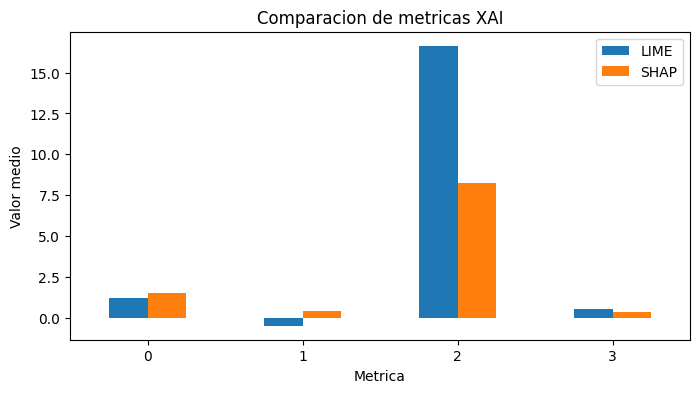

In [22]:
ax = comparison.plot.bar(figsize=(8, 4))
ax.set_title("Comparacion de metricas XAI")
ax.set_xlabel("Metrica")
ax.set_ylabel("Valor medio")
ax.tick_params(axis="x", rotation=0)